# [기초-실습] 통계 101x데이터 분석: (5-6장) 가설검정

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!pip install statsmodels
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 5.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.6 MB 4.5 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.6 MB 4.5 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.6 MB 4.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.6 MB 4.0 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.6 MB 4.0 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 3.8 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.6 MB 3.7 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 3.7 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 3.5 MB/s  0:00:02

   ------------------

'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [2]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 문제 1. 게임 아이템 뽑기 확률, 정말 10%일까? (난이도: 하)

**📘 문제**

- 어떤 게임 개발사에서 새로운 아이템의 뽑기 확률이 **10%**로 설정되었다고 주장하고 있습니다.

- 그런데 유저 커뮤니티에서는 "실제 확률은 10%보다 낮은 것 같다"는 의혹이 제기되었습니다.

- 이를 확인하기 위해 한 유저가 아이템을 **200번 뽑았고, 그중 12번 성공**했습니다.

- 이번 실습에서는 **이항검정(Binomial Test)**으로 이 결과가 개발사의 주장을 기각할 만큼 유의미한지 확인하고,
  시뮬레이션을 통해 **p-값이 무엇을 의미하는지**를 직접 눈으로 확인해 봅니다.

In [3]:
# 문제 설정
n = 200  # 총 시행 횟수
x = 12   # 관찰된 성공 횟수
p = 0.1  # 귀무가설에서의 성공 확률

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")

관찰 결과: 200번 시도 중 12번 성공 (관찰 성공률 6.0%)


**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 이항검정을 수행하여 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"만약 개발사의 주장대로 실제 확률이 정말 10%라면"** 200번 뽑기에서 성공 횟수가 어떻게 분포하는지 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 우리가 관찰한 '12번 성공'이 얼마나 희귀한 일인지 관찰해 봅시다.

In [4]:
# [문제 1] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 아이템의 실제 뽑기 확률은 개발사의 주장과 같다
# H₁ (대립가설): 아이템의 실제 뽑기 확률은 개발사의 주장보다 낮다

In [5]:
# [문제 1] Q2. 이항검정을 수행하고 p-값을 계산해봅시다.
# '확률이 더 낮은 것 같다'는 주장을 검증하려면 alternative 인수를 어떻게 설정해야 할까요?
# > 양측검정이 아닌 단측검정이니까 less

import numpy as np
from scipy import stats

n_trials = 200
n_success = 12
p_null = 0.10

# 커뮤니티 의혹: "실제 확률이 10%보다 낮다" -> 단측검정
result = stats.binomtest(n_success, n_trials, p_null, alternative='less')
p_value = result.pvalue

print(f"관찰된 성공 횟수: {n_success} / {n_trials}")
print(f"관찰된 성공률: {n_success/n_trials:.4f}")
print(f"p-value (단측검정): {p_value:.4f}")

관찰된 성공 횟수: 12 / 200
관찰된 성공률: 0.0600
p-value (단측검정): 0.0320


In [6]:
# [문제 1] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

alpha = 0.05

if p_value < alpha:
    conclusion = "귀무가설(H0)을 기각합니다. 실제 확률이 10%가 아니라는 유의미한 증거가 있습니다."
else:
    conclusion = "귀무가설(H0)을 기각하지 못합니다. 실제 확률이 10%와 다르다고 볼 유의미한 증거가 부족합니다."

print(f"유의수준(alpha): {alpha}")
print(f"p-value: {p_value:.4f}")
print(f"결론: {conclusion}")

유의수준(alpha): 0.05
p-value: 0.0320
결론: 귀무가설(H0)을 기각합니다. 실제 확률이 10%가 아니라는 유의미한 증거가 있습니다.


In [7]:
# [문제 1] Q4. H₀가 사실(실제 확률 = 10%)이라고 가정하고,
# 200번 뽑기를 10,000번 반복하는 시뮬레이션을 수행해봅시다.
# 힌트: numpy의 이항분포 랜덤 함수(np.random.binomial)를 사용해보세요.

# 시뮬레이션 설정
n_simulations = 10000
np.random.seed(42)  # 재현성을 위한 시드 고정

# H0가 사실이라고 가정 (실제 확률 = 10%)일 때,
# 200번 뽑기를 10,000번 반복하여 각 시행에서의 성공 횟수를 저장
simulated_successes = np.random.binomial(n=n_trials, p=p_null, size=n_simulations)

print(f"시뮬레이션 횟수: {n_simulations}")
print(f"시뮬레이션 성공 횟수 평균: {simulated_successes.mean():.2f}")
print(f"시뮬레이션 성공 횟수 표준편차: {simulated_successes.std():.2f}")

# 단측검정(alternative='less')에 맞춰서, 12 이하로 나온 경우만 카운트
extreme_count = np.sum(simulated_successes <= n_success)
simulated_p_value = extreme_count / n_simulations

print(f"시뮬레이션 기반 추정 p-value (단측): {simulated_p_value:.4f}")
print(f"(scipy 계산 p-value: {p_value:.4f}과 비교)")

시뮬레이션 횟수: 10000
시뮬레이션 성공 횟수 평균: 19.91
시뮬레이션 성공 횟수 표준편차: 4.21
시뮬레이션 기반 추정 p-value (단측): 0.0313
(scipy 계산 p-value: 0.0320과 비교)


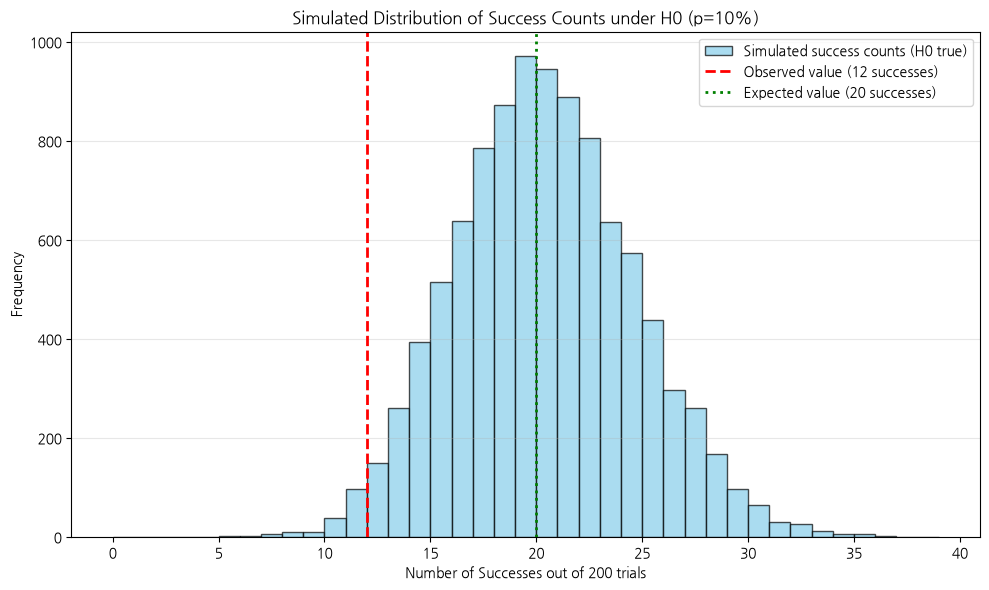

In [8]:
# [문제 1] Q5. 시뮬레이션 결과를 히스토그램으로 그려봅시다.
# 실제 관찰값(12번 성공)을 세로선으로 함께 표시해 봅시다.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 시뮬레이션 결과 히스토그램
plt.hist(simulated_successes, bins=range(0, 40), color='skyblue', 
          edgecolor='black', alpha=0.7, label='Simulated success counts (H0 true)')

# 실제 관찰값을 세로선으로 표시
plt.axvline(n_success, color='red', linestyle='--', linewidth=2, 
             label=f'Observed value ({n_success} successes)')

# 기대값(200 * 0.10 = 20)도 참고선으로 표시
plt.axvline(n_trials * p_null, color='green', linestyle=':', linewidth=2,
             label=f'Expected value ({n_trials * p_null:.0f} successes)')

plt.title('Simulated Distribution of Success Counts under H0 (p=10%)')
plt.xlabel('Number of Successes out of 200 trials')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- Q2에서 구한 p-값은 시뮬레이션 그래프의 어느 부분에 해당하며, 무엇을 의미하나요?

- 시뮬레이션 그래프를 볼 때, 우리가 관찰한 '12회 성공'은 개발사의 주장이 맞다는 가정 하에 흔한 일인가요, 드문 일인가요?

- 이 시뮬레이션 경험을 통해 "p-값이 작으면 귀무가설을 기각한다"는 규칙을 친구에게 어떻게 더 쉽게 설명할 수 있을까요?

- 만약 200번이 아니라 1,000번을 뽑아 같은 성공률(6%)이 나왔다면, p-값은 어떻게 달라질까요?

In [9]:
# [문제 1] 데이터를 어떻게 읽을까요?

# Q2에서 구한 p-값은 시뮬레이션 그래프의 빨간 점선 왼쪽에 있는 막대들의 넓이를 
# 전체 시뮬레이션 횟수(10,000)로 나눈 비율입니다.
# 이는 'H0가 사실일 때, 200번 중 12번 이하로 성공할 확률'을 뜻합니다.

# 그래프를 보면 대부분의 시뮬레이션 결과가 15~28 사이에 몰려있고
# 12는 왼쪽 꼬리 부분이어서 막대 길이가 짧습니다.
# p-값이 약 0.03이라는 것은 "H0이 맞다면 100번 중 3번만 일어나는 정도로
# 드문 일"이라는 뜻이기 때문에 H0을 기각하는 것입니다.

# "가챠를 돌려서 어떤 아이템 10개를 얻으면 너가 원하는 캐릭터 코스튬을 준데
# 그래서 너는 큰 마음을 먹고 엄청난 돈을 현질해가면서 까지
# 100번이나 돌렸는데, 이게 뭐야 총 원하는게 3개 밖에 안나왔네?
# 그러면 너는 "아 이 그지같은 게임.. 또 확률 조작하네"라고 생각하겠지?
# p-값이 작다는 건 이런 뜻이야 '우리가 본 결과가 순전히 운으로 나오기엔
# 너무 희귀하다'라는 신호인거지."

# 훨씬 더 작아집니다. 표본이 늘어나면 분포(표준편차)는 작아지는데
# 히스토그램을 생각해보면 표본은 늘어날수록 점점 분포가 중앙으로 맞춰집니다.
# 그 뜻은 양측의 꼬리가 점점 짧아지고 얇아진다는 뜻인데
# p-값이 양쪽 꼬리를 전체로 나눈 비율이라고하면 p-값이 작아지는게
# 더 이해가 갈 것 같습니다.

# 문제 2. 과자 한 봉지의 중량은 150g이 맞을까? (난이도: 하)

**📘 문제**

- 한 식품 공장에서 생산하는 과자 한 봉지의 **목표 중량은 150g**입니다.

- 품질관리팀은 생산 공정이 목표 중량을 잘 맞추고 있는지 확인하기 위해,
  생산된 과자 **30봉지를 무작위로 추출**하여 무게를 측정했습니다.

- 이번 실습에서는 **일표본 t-검정(One-sample t-Test)**으로 표본 평균이 목표 중량과 유의미하게 다른지 검증하고,
  **"평균이 정확히 150g이라면"** 어떤 표본 평균들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

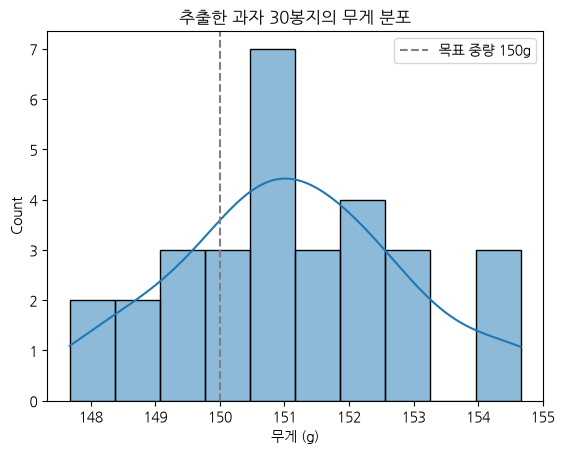

In [10]:
# 데이터 생성 (과자 30봉지의 무게 측정값)
np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150  # 목표 중량 (모평균)

# 표본 분포 시각화
sns.histplot(sample_weights, bins=10, kde=True)
plt.axvline(x=pop_mean, color='gray', linestyle='--', label='목표 중량 150g')
plt.title("추출한 과자 30봉지의 무게 분포")
plt.xlabel("무게 (g)")
plt.legend()
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 일표본 t-검정을 수행하여 t-통계량과 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"평균 무게가 정확히 150g이라면"** 30개짜리 표본의 평균이 어떻게 분포하는지 10,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 표본 평균이 그 분포에서 어디에 위치하는지 관찰해 봅시다.

In [11]:
# [문제 2] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 평균 무게가 150일 것이다.
# H₁ (대립가설): 평균 무게가 150이 아닐 것이다.

# -> 품질관리 관점에서는 "너무 많이 들었는지" 또는 "너무 적게 들었는지"
#    양쪽 방향 모두가 문제가 되므로, 양측검정을 사용한다.

In [12]:
# [문제 2] Q2. 일표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.

import numpy as np
from scipy import stats

# 실습용 예시 데이터: 무작위 추출한 30봉지의 무게(g)
# ※ 실제 측정 데이터가 있다면 이 부분을 그 값으로 교체하세요.
np.random.seed(42)
weights = np.round(np.random.normal(loc=148.5, scale=4.0, size=30), 1)

target_weight = 150  # 목표 중량 (H0)

print("측정된 30봉지 무게:")
print(weights)
print(f"\n표본 평균: {weights.mean():.3f} g")
print(f"표본 표준편차: {weights.std(ddof=1):.3f} g")

# 일표본 t-검정 수행
t_stat, p_value = stats.ttest_1samp(weights, target_weight)

print(f"\nt-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

측정된 30봉지 무게:
[150.5 147.9 151.1 154.6 147.6 147.6 154.8 151.6 146.6 150.7 146.6 146.6
 149.5 140.8 141.6 146.3 144.4 149.8 144.9 142.9 154.4 147.6 148.8 142.8
 146.3 148.9 143.9 150.  146.1 147.3]

표본 평균: 147.750 g
표본 표준편차: 3.608 g

t-통계량: -3.4161
p-value: 0.0019


In [13]:
# [문제 2] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

alpha = 0.05

if p_value < alpha:
    conclusion = "귀무가설(H0)을 기각합니다. 실제 평균 중량이 150g과 유의미하게 다르다는 증거가 있습니다."
else:
    conclusion = "귀무가설(H0)을 기각하지 못합니다. 실제 평균 중량이 150g과 다르다고 볼 유의미한 증거가 부족합니다."

print(f"유의수준(alpha): {alpha}")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"결론: {conclusion}")

유의수준(alpha): 0.05
t-통계량: -3.4161
p-value: 0.0019
결론: 귀무가설(H0)을 기각합니다. 실제 평균 중량이 150g과 유의미하게 다르다는 증거가 있습니다.


In [14]:
# [문제 2] Q4. H₀가 사실(평균 = 150g)이라고 가정하고, 30개짜리 표본을 10,000번 뽑아
# 각 표본의 평균을 리스트에 저장해봅시다.
# 힌트: 표준편차는 우리가 가진 표본의 표준편차를 사용한다고 가정하고, for 반복문을 사용해보세요.

# H0가 사실이라고 가정 (실제 평균 = 150g)
# 표준편차는 우리가 가진 표본의 표준편차를 그대로 사용한다고 가정
n_samples = 30
n_simulations = 10000
sample_std = weights.std(ddof=1)  # 우리가 관찰한 표본의 표준편차

simulated_means = []

for i in range(n_simulations):
    # 평균 150, 표준편차 sample_std인 정규분포에서 30개를 뽑아 표본 생성
    simulated_sample = np.random.normal(loc=target_weight, scale=sample_std, size=n_samples)
    simulated_means.append(simulated_sample.mean())

simulated_means = np.array(simulated_means)

print(f"시뮬레이션 횟수: {n_simulations}")
print(f"시뮬레이션 표본평균의 평균: {simulated_means.mean():.3f} g")
print(f"시뮬레이션 표본평균의 표준편차: {simulated_means.std():.3f} g")
print(f"우리가 실제로 관찰한 표본평균: {weights.mean():.3f} g")

시뮬레이션 횟수: 10000
시뮬레이션 표본평균의 평균: 150.001 g
시뮬레이션 표본평균의 표준편차: 0.665 g
우리가 실제로 관찰한 표본평균: 147.750 g


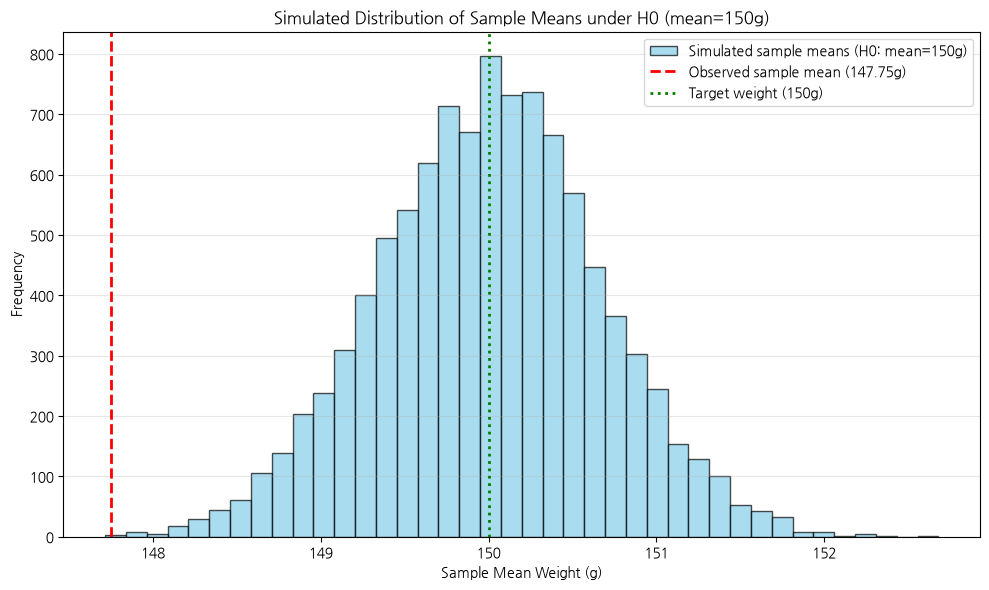

In [15]:
# [문제 2] Q5. 시뮬레이션으로 얻은 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 표본 평균을 세로선으로 함께 표시해 봅시다.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 시뮬레이션으로 얻은 표본평균들의 히스토그램
plt.hist(simulated_means, bins=40, color='skyblue', edgecolor='black', 
          alpha=0.7, label='Simulated sample means (H0: mean=150g)')

# 실제 관찰된 표본 평균을 세로선으로 표시
observed_mean = weights.mean()
plt.axvline(observed_mean, color='red', linestyle='--', linewidth=2,
             label=f'Observed sample mean ({observed_mean:.2f}g)')

# 목표 중량(150g)도 참고선으로 표시
plt.axvline(target_weight, color='green', linestyle=':', linewidth=2,
             label=f'Target weight ({target_weight}g)')

plt.title('Simulated Distribution of Sample Means under H0 (mean=150g)')
plt.xlabel('Sample Mean Weight (g)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- Q5의 히스토그램은 무엇을 나타내나요? 이 분포의 모양이 정규분포와 비슷한 이유는 무엇일까요? (힌트: 4장에서 배운 중심극한정리)

- 우리가 실제로 관찰한 표본 평균(세로선)은 이 분포에서 흔하게 나타나는 값인가요? Q2의 p-값과 이 시각적 위치는 어떻게 관련되나요?

- 만약 p-값이 0.001이었다면, 세로선은 그래프의 어디쯤에 위치할 것으로 예상되나요?

- 이 결과는 공장 입장에서 어떤 조치를 취해야 함을 시사할까요? (목표보다 무겁게 나오는 것은 어떤 손실일까요?)

In [16]:
# [문제 2] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

# Q5의 히스토그램은 '만약 공장의 실제 평균 중량이 "평균 무게가 정확히 150g이라면" 30개짜리 표본을 뽑을 때 나올 수 있는
# 표본 평균을 10,000번 뽑아본 결과' 입니다. 즉 각각의 값이 개별과자의 값이 아닌
# 표본평균이라는 값이 중요합니다.
# 종 모양의 정규분포를 띄는 이유는 중심극한정리 때문입니다. 
# 개별 과자의 무게 분포가 어떻든지 간에 표본 크기가 어느정도 이상이 되면
# 표본평균들의 분포는 정규분포에 가까워집니다.

# 그래프를 보면 빨간 점선이 맨 왼쪽 끝에 있습니다.
# 왼쪽 끝에는 히스토그램 막대가 거의 없다싶이 짧죠.
# 즉, 150g이 정말 과자의 평균 무게라는 가정하에서는
# 147.75g과 같은 무게의 표본 평균이 나올 확률은 매우 드물다라는 뜻입니다.
# Q2에서 나온 p-값이 0.0019이라는 뜻은 약 10000번 무게를 쟀을 때
# 147.75라는 극단적인 값이 19번 정도 밖에 안나온다라는 뜻입니다.
# 이렇게 보면 히스토그램에서 빨간선이 왜이렇게 왼쪽 끝에 있는지도 
# 더 쉽게 이해할 수 있죠

# 0.0019 > 0.001 이죠 즉, 약 10000번 무게를 쟀으면 이번엔 극단적인 값이
# 10번만 나온다는 뜻입니다. 19번 보다 더 적은 경우의 수이죠. 그렇다면 
# 히스토그램에서는 지금보다 더 왼쪽으로 갈 것입니다. 
# 경우의 수가 그 지점부터 꼬리 끝까지 누적된 넓이라고 생각할 때 
# 선이 더 왼쪽으로 간다는 것은 그 넓이(경우의 수)도 더 적어지니 
# 머리에서 그려보면 더 이해가 쉬울 것 같습니다.

# 결론적으로 평균무게는 공장이 목표한 150g보다 적게 나왔습니다.
# 소비자 입장에서는 약 '3g정도 중량을 적게 넣은 브랜드'라고 인식할 수 있습니다.
# 이는 소비자 신뢰문제와 법적 리스크로 넘어갈 수 있기 때문에 
# 눈금 조정 점검, 중량 증가 등의 조치가 필요합니다.
# 반대상황이라면 소비자 입장에서는 좋지만 공장의 입장에서는 원가 손실입니다.
# 계획보다 더 많은 원료를 매 봉지마다 사용한다는 뜻이니 생산량 전체로 보면
# 적지 않은 금액입니다. 적게 나가면 소비자/법적 문제, 많이 나가면 원가문제이죠.
# 이렇기 때문에 회사는 양방향으로 리스크를 관리해야하고 이것이 우리가 앞선 분석에서
# 양측검정을 선택한 이유입니다. 


# 문제 3. 어떤 온라인 학습 방식이 더 효과적일까? (난이도: 중)

**📘 문제**

- 한 교육 기업에서 두 가지 다른 온라인 학습 방식(A, B)을 개발했습니다.

- 방식 A가 방식 B보다 학생들의 성적 향상에 더 효과적인지 알아보기 위해,
  두 그룹의 학생들에게 각각 다른 방식으로 한 달간 학습시킨 후 시험을 보게 했습니다.

- 이번 실습에서는 **이표본 t-검정(Two-sample t-Test)**으로 두 방식의 평균 점수 차이를 검증합니다.
  단, t-검정의 기본 가정인 **정규성**과 **등분산성**을 먼저 확인해야 합니다.

- 또한 **"두 방식의 효과가 완전히 똑같다면"** 우연히 나타날 수 있는 점수 차이의 범위를 시뮬레이션으로 확인해 봅니다.

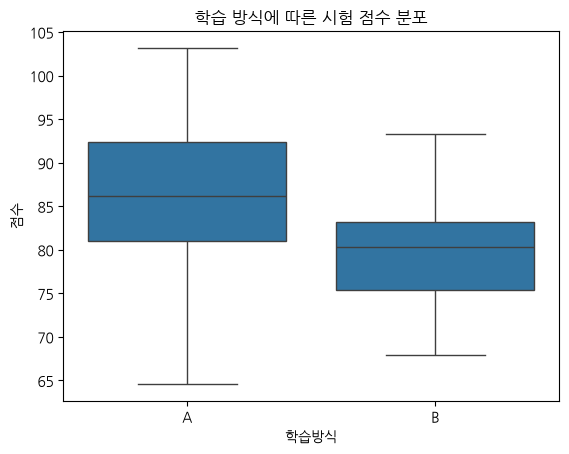

In [17]:
# 데이터 생성 (두 학습 방식의 시험 점수)
np.random.seed(0)
group_a_scores = np.random.normal(loc=85, scale=8, size=50)
group_b_scores = np.random.normal(loc=80, scale=7, size=50)

df_scores = pd.DataFrame({'점수': np.concatenate([group_a_scores, group_b_scores]),
                          '학습방식': ['A']*50 + ['B']*50})

# 두 그룹의 점수 분포 시각화
sns.boxplot(x='학습방식', y='점수', data=df_scores)
plt.title("학습 방식에 따른 시험 점수 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 두 그룹에 대해 **정규성 검정(Shapiro-Wilk test)**을 수행해 봅시다. (H₀: 데이터는 정규분포를 따른다.)

- **등분산성 검정(Levene's test)**을 수행해 봅시다. (H₀: 두 그룹의 분산은 같다.)

- 가정 검토 결과에 따라 `equal_var` 인수를 설정하여 **이표본 t-검정**을 수행해 봅시다.

- 두 그룹 데이터를 모두 합친 뒤 무작위로 다시 나누는 방식으로, **"두 방식의 효과가 같을 때"**의 평균 차이 분포를 시뮬레이션해 봅시다.

In [18]:
# [문제 3] Q1. 두 그룹에 대해 각각 정규성 검정(Shapiro-Wilk test)을 수행하고 p-값을 출력해봅시다.
# H₀: 데이터는 정규분포를 따른다.

# H0: 데이터는 정규분포를 따른다.
shapiro_a = stats.shapiro(group_a_scores)
shapiro_b = stats.shapiro(group_b_scores)

print(f"A그룹 Shapiro-Wilk p-value: {shapiro_a.pvalue:.4f}")
print(f"B그룹 Shapiro-Wilk p-value: {shapiro_b.pvalue:.4f}")

alpha = 0.05
print(f"\nA그룹: {'정규성 만족 (H0 기각 못함)' if shapiro_a.pvalue >= alpha else '정규성 위반 (H0 기각)'}")
print(f"B그룹: {'정규성 만족 (H0 기각 못함)' if shapiro_b.pvalue >= alpha else '정규성 위반 (H0 기각)'}")

A그룹 Shapiro-Wilk p-value: 0.8766
B그룹 Shapiro-Wilk p-value: 0.8366

A그룹: 정규성 만족 (H0 기각 못함)
B그룹: 정규성 만족 (H0 기각 못함)


In [19]:
# [문제 3] Q2. 두 그룹에 대해 등분산성 검정(Levene's test)을 수행하고 p-값을 출력해봅시다.
# H₀: 두 그룹의 분산은 같다.

# H0: 두 그룹의 분산은 같다.
levene_result = stats.levene(group_a_scores, group_b_scores)

print(f"Levene's test p-value: {levene_result.pvalue:.4f}")

equal_var_assumption = levene_result.pvalue >= alpha
print(f"등분산성 가정: {'만족 (H0 기각 못함)' if equal_var_assumption else '위반 (H0 기각)'}")

Levene's test p-value: 0.0150
등분산성 가정: 위반 (H0 기각)


In [20]:
# [문제 3] Q3. 이표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.
# H₀: 두 그룹의 평균은 같다. / H₁: 두 그룹의 평균은 다르다.
# 등분산성 가정을 만족했는지 여부에 따라 equal_var 인수를 설정해보세요.

# H0: 두 그룹의 평균은 같다 (μA = μB)
# H1: 두 그룹의 평균은 다르다 (μA ≠ μB)

t_stat, p_value = stats.ttest_ind(group_a_scores, group_b_scores, equal_var=equal_var_assumption)

print(f"등분산 가정 여부: {equal_var_assumption}")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

print(f"\nA그룹 평균: {group_a_scores.mean():.3f}")
print(f"B그룹 평균: {group_b_scores.mean():.3f}")
observed_diff = group_a_scores.mean() - group_b_scores.mean()
print(f"관찰된 평균 차이 (A - B): {observed_diff:.3f}")

if p_value < alpha:
    print("\n결론: 귀무가설(H0)을 기각합니다. 두 방식의 평균 점수는 유의미하게 다릅니다.")
else:
    print("\n결론: 귀무가설(H0)을 기각하지 못합니다. 두 방식의 평균 점수가 다르다고 볼 유의미한 증거가 부족합니다.")

등분산 가정 여부: False
t-통계량: 4.0426
p-value: 0.0001

A그룹 평균: 86.124
B그룹 평균: 79.853
관찰된 평균 차이 (A - B): 6.271

결론: 귀무가설(H0)을 기각합니다. 두 방식의 평균 점수는 유의미하게 다릅니다.


In [21]:
# [문제 3] Q4. H₀가 사실(두 그룹의 평균이 같다)이라고 가정하고 시뮬레이션을 10,000번 수행해봅시다.
# 두 그룹의 데이터를 모두 합친 뒤(np.concatenate), 매 반복마다 비복원추출로 50개(가상 A그룹)와
# 나머지 50개(가상 B그룹)로 나누어 두 그룹의 평균 차이를 계산하고 리스트에 저장해보세요.
# 힌트: np.random.permutation 을 사용해보세요.

# H0가 사실이라고 가정 (두 그룹의 평균은 같다)
# -> 두 그룹의 데이터를 합친 후, 매번 무작위로 50개/50개씩 다시 나눠서
#    "만약 방식의 차이가 진짜 없다면" 우연히 나올 수 있는 평균 차이들을 시뮬레이션

n_simulations = 10000
combined = np.concatenate([group_a_scores, group_b_scores])
n_a = len(group_a_scores)  # 50

np.random.seed(42)
simulated_diffs = []

for i in range(n_simulations):
    shuffled = np.random.permutation(combined)
    pseudo_a = shuffled[:n_a]        # 가상 A그룹 50개
    pseudo_b = shuffled[n_a:]        # 가상 B그룹 나머지 50개
    diff = pseudo_a.mean() - pseudo_b.mean()
    simulated_diffs.append(diff)

simulated_diffs = np.array(simulated_diffs)

print(f"시뮬레이션 횟수: {n_simulations}")
print(f"시뮬레이션 평균 차이의 평균: {simulated_diffs.mean():.3f}")
print(f"시뮬레이션 평균 차이의 표준편차: {simulated_diffs.std():.3f}")
print(f"실제 관찰된 평균 차이: {observed_diff:.3f}")

# 순열검정 기반 p-value (양측)
permutation_p_value = np.sum(np.abs(simulated_diffs) >= np.abs(observed_diff)) / n_simulations
print(f"순열검정 기반 p-value: {permutation_p_value:.4f}")
print(f"(t-검정 p-value: {p_value:.4f}과 비교)")

시뮬레이션 횟수: 10000
시뮬레이션 평균 차이의 평균: -0.016
시뮬레이션 평균 차이의 표준편차: 1.656
실제 관찰된 평균 차이: 6.271
순열검정 기반 p-value: 0.0001
(t-검정 p-value: 0.0001과 비교)


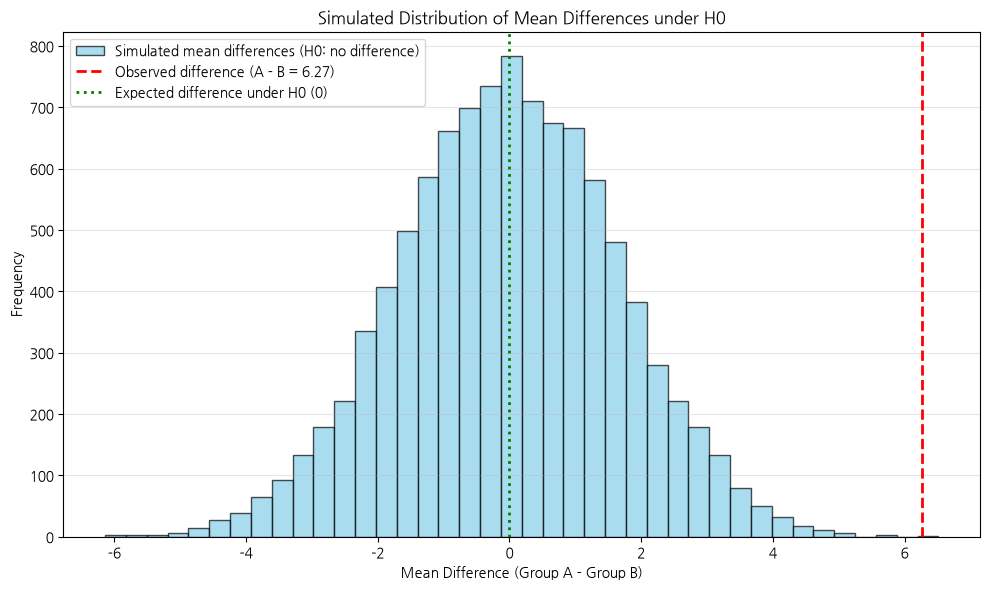

In [22]:
# [문제 3] Q5. 시뮬레이션으로 얻은 평균 차이의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 평균 차이(A그룹 평균 - B그룹 평균)를 세로선으로 함께 표시해 봅시다.

plt.figure(figsize=(10, 6))

plt.hist(simulated_diffs, bins=40, color='skyblue', edgecolor='black',
          alpha=0.7, label='Simulated mean differences (H0: no difference)')

plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2,
             label=f'Observed difference (A - B = {observed_diff:.2f})')

plt.axvline(0, color='green', linestyle=':', linewidth=2,
             label='Expected difference under H0 (0)')

plt.title('Simulated Distribution of Mean Differences under H0')
plt.xlabel('Mean Difference (Group A - Group B)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 정규성 검정과 등분산성 검정의 p-값은 각각 어떻게 해석해야 하나요? 이 결과는 이표본 t-검정을 사용하는 데 문제가 없음을 보여주나요?

- Q5의 히스토그램 중심이 0에 가까운 이유는 무엇일까요?

- 실제 관찰된 평균 차이(세로선)는 "두 방식의 효과가 같다"고 가정했을 때 우연히 나타날 수 있는 범위 안에 있나요, 벗어나나요?

- 이 시각적 판단과 Q3의 p-값은 어떤 관계가 있나요?

- 통계적으로 유의미한 차이가 있다면, 교육 기업은 이 결과를 어떻게 활용할 수 있을까요?

In [23]:
# [문제 3] 데이터를 어떻게 읽을까요?

# 정규성 검정에서는 H0을 '정규분포를 따른다.'라고 가정합니다.
# 이때 A그룹 p=0.8766, B그룹 p=0.8366 둘 다 0.05보다 훨씬 큽니다.
# 이건 H0을 기각할 근거가 없다는 뜻이니 두 그룹 모두 정규성을 만족합니다.
# 등분산성 역시 H0은 '두 그룹의 분산이 같다.'라고 판단합니다.
# 이때 p=0.0150 이기 때문에  "두 그룹의 분산이 같다"는 
# H0을 기각하게 되고, 실제로는 두 그룹의 분산이 다르다고 판단합니다.
# 이 두 결과를 종합하면 결국, 정규성은 만족하지만 등분산성은 위반한 상태이기 떄문에
# Student's t-test 대신 Welch's t-test(equal_var=False)를 쓰면 됩니다.

# Q5에서 그린 히스토그램은 "H0가 사실이라면(즉 A방식과 B방식의 진짜 효과가 완전히 같다면) 
# 우연히 나뉜 두 그룹의 평균 차이가 어떻게 분포할까"를 시뮬레이션한 것입니다.
# 그래서 A가 더 높을 수도, B가 더 높을 수도 있었던 확률이 평균적으로
# 상쇄되면서, 차이의 평균이 0 근처로 몰리게 됩니다.

# 그래프를 보면 완전히 벗어나있다는 것을 확인할 수 있습니다. 
# 자세한 사항은 위에서 많이 언급해서 넘어가겠습니다.

# 결국 같은 얘기를 두 방법으로 보여주고 있습니다.
# 그래프는 빨간 선이 오른쪽 꼬리에 있다로, p-값은 10,000번 중 한번꼴로 극단값이 나온다로.
# 이 두 결과는 결론적으로 두 방식의 차이는 유의미하게 존재한다는 것을 말합니다.

# 두 방식의 차이가 있고, A과정의 평균이 높은 것을 확인했으니,
# 교육 기업은 A방식을 표준 커리큘럼으로 채택할 수 있습니다.
# p-값은 차이의 유무만 검증하는 도구이기 때문에 후속 검증을 통해
# 그럼 차이가 얼마나 나는가를 보고하면 더 완성된 보고가 될 수 있을 것입니다.
# 혹은 이 근거는 잠시 넣어두고 운영 비용, 개발 환경 등 다른 지표를 더 이용해사
# 우리가 세운 'A 방식이 더 탁월하다.'라는 주장을 뒷받침 할 수도 있습니다.

# 문제 4. 연령대별로 선호하는 영화 장르가 다를까? (난이도: 중)

**📘 문제**

- 한 영화관에서 고객의 **연령대(20대, 30대, 40대)**에 따라 선호하는 **영화 장르(액션, 로맨스)**에 차이가 있는지 궁금해졌습니다.

- 이를 알아보기 위해 300명의 고객을 대상으로 설문조사를 진행하여 분할표를 얻었습니다.

- 이번 실습에서는 **카이제곱 독립성 검정(Chi-squared Test of Independence)**으로
  두 범주형 변수 사이에 연관성이 있는지 검증합니다.

- 또한 **"두 변수가 서로 아무 관련이 없다면(독립이라면)"** 어떤 카이제곱 통계량들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

관측 빈도 (Observed Frequencies):
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60


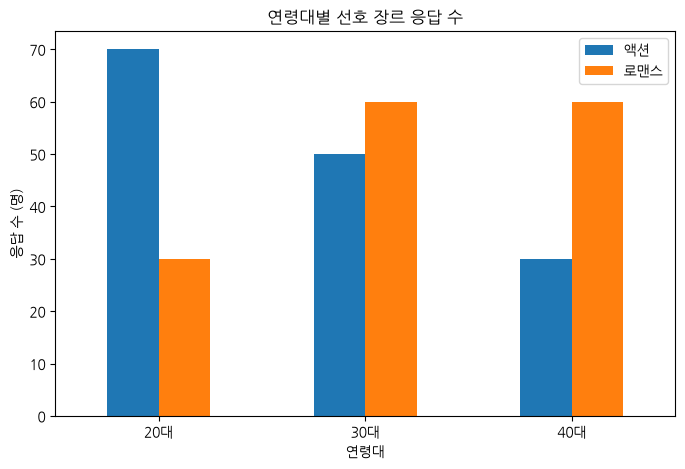

In [24]:
# 데이터 생성 (관측 빈도 분할표)
data = {'액션': [70, 50, 30],
        '로맨스': [30, 60, 60]}
observed = pd.DataFrame(data, index=['20대', '30대', '40대'])

print("관측 빈도 (Observed Frequencies):")
print(observed)

# 분할표 시각화
observed.plot(kind='bar', figsize=(8, 5))
plt.title("연령대별 선호 장르 응답 수")
plt.xlabel("연령대")
plt.ylabel("응답 수 (명)")
plt.xticks(rotation=0)
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 카이제곱 독립성 검정을 수행하여 카이제곱 통계량, p-값, 자유도, **기대 빈도**를 구해봅시다.

- **"연령대와 선호 장르가 독립이라면"** 어떤 분할표들이 나타날 수 있는지 5,000번 시뮬레이션해 봅시다.

- 시뮬레이션으로 얻은 카이제곱 통계량 분포와 실제 관찰된 카이제곱 통계량을 비교해 봅시다.

In [25]:
# [문제 4] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 연령대와 선호 장르는 서로 독립적이다.
# H₁ (대립가설): 연령대와 선호 장르는 서로 독립적이지 않다

In [26]:
# [문제 4] Q2. 카이제곱 독립성 검정을 수행하고 카이제곱 통계량, p-값, 자유도, 기대 빈도를 구해봅시다.
# 기대 빈도는 관측 빈도와 비교하기 쉽도록 데이터프레임 형태로 출력해보세요.

chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

print(f"카이제곱 통계량 (Chi2): {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"자유도 (degrees of freedom): {dof}")

# 기대 빈도를 관측 빈도와 같은 형태의 데이터프레임으로 변환
expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
print("\n기대 빈도 (Expected Frequencies):")
print(expected_df.round(2))

print("\n관측 빈도 (Observed Frequencies):")
print(observed)

alpha = 0.05
if p_value < alpha:
    print(f"\n결론: 귀무가설(H0)을 기각합니다. 연령대와 선호 장르는 유의미한 연관성이 있습니다.")
else:
    print(f"\n결론: 귀무가설(H0)을 기각하지 못합니다. 연령대와 선호 장르가 연관되어 있다고 볼 유의미한 증거가 부족합니다.")

카이제곱 통계량 (Chi2): 26.9091
p-value: 0.0000
자유도 (degrees of freedom): 2

기대 빈도 (Expected Frequencies):
       액션   로맨스
20대  50.0  50.0
30대  55.0  55.0
40대  45.0  45.0

관측 빈도 (Observed Frequencies):
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60

결론: 귀무가설(H0)을 기각합니다. 연령대와 선호 장르는 유의미한 연관성이 있습니다.


In [27]:
# [문제 4] Q3. H₀가 사실(두 변수가 독립)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 각 반복마다 300명의 가상 고객에게 연령대와 장르를 '독립적으로' 할당한 후,
# 가상 분할표를 만들고 카이제곱 통계량을 계산하여 리스트에 저장해보세요.
# 힌트 1: 전체 비율(observed.sum(axis=0) / 전체, observed.sum(axis=1) / 전체)을 확률로 사용
# 힌트 2: np.random.choice 로 300명의 연령대와 장르를 각각 독립적으로 생성
# 힌트 3: pd.crosstab 으로 분할표 생성 후 stats.chi2_contingency 로 통계량 계산

# H0가 사실이라고 가정 (연령대와 장르는 독립)
# -> 전체 마진(marginal) 비율만 사용해서, 각 고객에게
#    연령대와 장르를 서로 '독립적으로' 무작위 배정한 뒤
#    가상 분할표를 만들고 카이제곱 통계량을 계산

total = observed.sum().sum()  # 전체 300명

# 연령대 비율 (행 합 / 전체)
age_probs = observed.sum(axis=1) / total   # 20대, 30대, 40대 각각의 비율
# 장르 비율 (열 합 / 전체)
genre_probs = observed.sum(axis=0) / total  # 액션, 로맨스 각각의 비율

print("연령대 비율:\n", age_probs)
print("\n장르 비율:\n", genre_probs)

n_simulations = 5000
np.random.seed(42)
simulated_chi2 = []

for i in range(n_simulations):
    # 300명에게 연령대와 장르를 각각 독립적으로 무작위 배정
    sim_ages = np.random.choice(age_probs.index, size=total, p=age_probs.values)
    sim_genres = np.random.choice(genre_probs.index, size=total, p=genre_probs.values)

    # 가상 분할표 생성
    sim_table = pd.crosstab(sim_ages, sim_genres)

    # 카이제곱 통계량 계산
    sim_chi2, _, _, _ = stats.chi2_contingency(sim_table)
    simulated_chi2.append(sim_chi2)

simulated_chi2 = np.array(simulated_chi2)

print(f"\n시뮬레이션 횟수: {n_simulations}")
print(f"시뮬레이션 카이제곱 통계량 평균: {simulated_chi2.mean():.4f}")
print(f"실제 관찰된 카이제곱 통계량: {chi2_stat:.4f}")

# 시뮬레이션 기반 p-value: 관찰값보다 크거나 같은 카이제곱이 나온 비율
simulated_p_value = np.sum(simulated_chi2 >= chi2_stat) / n_simulations
print(f"시뮬레이션 기반 p-value: {simulated_p_value:.4f}")
print(f"(scipy 계산 p-value: {p_value:.4f}과 비교)")

연령대 비율:
 20대    0.333333
30대    0.366667
40대    0.300000
dtype: float64

장르 비율:
 액션     0.5
로맨스    0.5
dtype: float64

시뮬레이션 횟수: 5000
시뮬레이션 카이제곱 통계량 평균: 2.0263
실제 관찰된 카이제곱 통계량: 26.9091
시뮬레이션 기반 p-value: 0.0000
(scipy 계산 p-value: 0.0000과 비교)


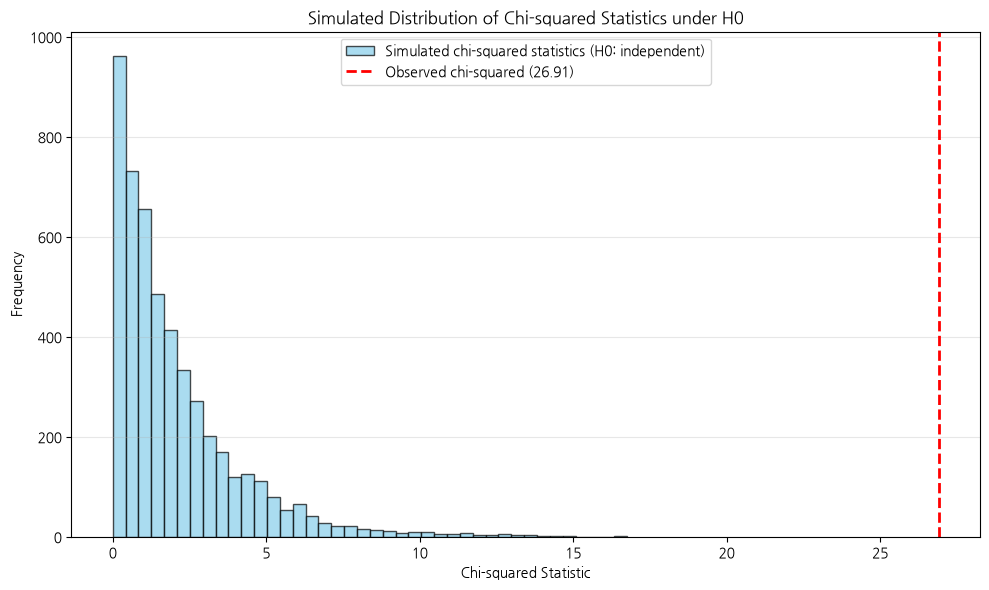

In [28]:
# [문제 4] Q4. 시뮬레이션으로 얻은 카이제곱 통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 카이제곱 통계량을 세로선으로 함께 표시해 봅시다.

plt.figure(figsize=(10, 6))

plt.hist(simulated_chi2, bins=40, color='skyblue', edgecolor='black',
          alpha=0.7, label='Simulated chi-squared statistics (H0: independent)')

plt.axvline(chi2_stat, color='red', linestyle='--', linewidth=2,
             label=f'Observed chi-squared ({chi2_stat:.2f})')

plt.title('Simulated Distribution of Chi-squared Statistics under H0')
plt.xlabel('Chi-squared Statistic')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- '기대 빈도'는 어떤 의미를 가지며, '관측 빈도'와의 차이가 클수록 카이제곱 통계량은 어떻게 변할까요?

- Q4의 히스토그램은 어떤 분포를 시각화한 것인가요? 실제 관찰된 카이제곱 통계량(세로선)은 흔한 값인가요, 극단적인 값인가요?

- 유의수준 0.05에서, 연령대와 선호 장르 사이에 통계적으로 유의미한 연관성이 있다고 결론 내릴 수 있나요? 그 이유는 무엇인가요?

- 이 결과를 바탕으로 영화관은 연령대별로 어떤 상영 전략이나 프로모션을 세울 수 있을까요?

In [29]:
# [문제 4] 데이터를 어떻게 읽을까요?

# 기대 빈도는 "만약 연령대와 선호 장르가 정말로 아무 관련이 없다면(완전히 독립이라면), 
# 각 칸에 몇 명이 나와야 할까?"를 계산한 값입니다. 
# 데이터에서는 전체적으로 액션:로맨스 = 50:50 비율이니까,
# 20대 중에서도 액션 50명, 로맨스 50명이 나오는 게 
# "아무 연관 없을 때의 자연스러운 결과"라는 것입니다.

# "연령대와 장르가 정말 독립이라면, 300명씩 무작위로 배정해서 분할표를 
# 만들 때마다 나올 수 있는 카이제곱 통계량들"을 5,000번 시뮬레이션한 분포입니다.

# 네, 명확하게 그렇습니다. p-value가 0.0000(더 정확히는 아주 작은 값)으로 
# 0.05보다 훨씬 작기 때문에, 귀무가설(연령대와 선호 장르는 독립이다)을 기각합니다.

# 20대는 액션을 압도적으로 선호하기 때문데 20대가 주로 몰리는 시간대에는
# 액셩 상영 비중을 늘리고 20대 카겟 마케팅으로는 액션 신작 위주로 집중할 수 있습니다.
# 또한 40대는 로맨스를 선호하기 때문에 마찬가지로 0대가 상대적으로 
# 많이 찾는 시간대에는 로맨스/드라마 장르 편성을 늘릴 수 있습니다.
# 30대는 액션/로맨스 선호가 반반이니, 이 연령대에는 두 장르를 고르게 편성하거나, 
# 두 장르 외의 다른 취향(예: 코미디, 스릴러)을 추가로 조사해서 
# 세분화된 전략을 짜볼 수도 있어요

# 문제 5. 미니 프로젝트 - 어떤 신규 비료가 가장 효과적일까? (난이도: 상)

**📘 문제**

- 한 농업 연구소에서 새로 개발한 비료 3종류(A, B, C)의 생산량 증대 효과를 비교하고자 합니다.

- 동일한 조건의 밭 30개를 준비하여, 각각 10개씩 비료 A, B, C를 투여한 후 수확량을 측정했습니다.

- 이번 실습에서는 **분산분석(ANOVA)**으로 세 비료 간 평균 수확량에 차이가 있는지 검증하고,
  차이가 있다면 **사후분석(Tukey's HSD)**으로 어떤 비료끼리 차이가 나는지 확인합니다.

- 마지막으로 **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량이 나올 수 있는지 시뮬레이션하고,
  분석 결과를 바탕으로 연구소에 어떤 비료를 추천할지까지 생각해 봅니다.

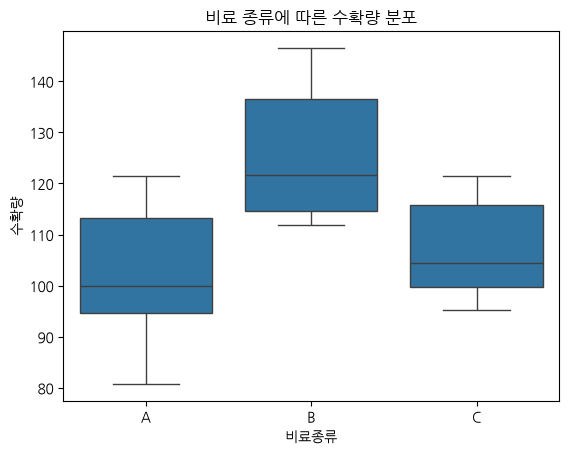

In [30]:
# 데이터 생성 (비료 종류별 수확량)
np.random.seed(123)
fertilizer_a = np.random.normal(loc=105, scale=10, size=10)
fertilizer_b = np.random.normal(loc=120, scale=12, size=10)
fertilizer_c = np.random.normal(loc=108, scale=9, size=10)

# 데이터프레임으로 변환 (사후분석을 위해)
df = pd.DataFrame({'수확량': np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c]),
                   '비료종류': ['A']*10 + ['B']*10 + ['C']*10})

# 데이터 탐색 시각화
sns.boxplot(x='비료종류', y='수확량', data=df)
plt.title("비료 종류에 따른 수확량 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 세 그룹에 대해 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.

- ANOVA 결과가 유의미할 경우에만 **Tukey's HSD 사후분석**을 수행하고 결과를 해석해 봅시다.

- **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량들이 나오는지 5,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 F-통계량이 얼마나 극단적인 값인지 확인해 봅시다.

- 분석 결과를 종합하여 연구소에 추천할 비료를 정해 봅시다.

In [31]:
# [문제 5] Q1. 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.
# H₀: 세 비료의 평균 수확량은 모두 같다.
# H₁: 적어도 하나 이상의 비료 평균 수확량은 다르다.

# H0: 세 비료의 평균 수확량은 모두 같다.
# H1: 적어도 하나 이상의 비료 평균 수확량은 다르다.

f_stat, p_value = stats.f_oneway(fertilizer_a, fertilizer_b, fertilizer_c)

print(f"F-통계량: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")

print(f"\nA비료 평균: {fertilizer_a.mean():.3f}")
print(f"B비료 평균: {fertilizer_b.mean():.3f}")
print(f"C비료 평균: {fertilizer_c.mean():.3f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n결론: 귀무가설(H0)을 기각합니다. 적어도 하나의 비료는 평균 수확량이 다릅니다.")
else:
    print(f"\n결론: 귀무가설(H0)을 기각하지 못합니다. 세 비료의 평균 수확량이 다르다고 볼 유의미한 증거가 부족합니다.")

F-통계량: 10.3455
p-value: 0.0005

A비료 평균: 102.305
B비료 평균: 125.980
C비료 평균: 107.148

결론: 귀무가설(H0)을 기각합니다. 적어도 하나의 비료는 평균 수확량이 다릅니다.


In [32]:
# [문제 5] Q2. ANOVA의 p-값이 유의수준 0.05보다 작을 경우에만
# Tukey's HSD 사후분석을 수행하고 결과를 출력해봅시다.
# 힌트: pairwise_tukeyhsd(endog=수확량, groups=비료종류, alpha=0.05)

if p_value < alpha:
    print("ANOVA 결과가 유의미하므로 사후분석(Tukey's HSD)을 수행합니다.\n")
    
    tukey_result = pairwise_tukeyhsd(endog=df['수확량'], groups=df['비료종류'], alpha=0.05)
    print(tukey_result)
else:
    print("ANOVA 결과가 유의미하지 않으므로 사후분석을 수행하지 않습니다.")

ANOVA 결과가 유의미하므로 사후분석(Tukey's HSD)을 수행합니다.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  23.6754 0.0006  10.0402 37.3106   True
     A      C   4.8429 0.6569  -8.7923 18.4781  False
     B      C -18.8325 0.0054 -32.4677 -5.1972   True
-----------------------------------------------------


In [33]:
# [문제 5] Q3. H₀가 사실(세 그룹의 평균이 모두 같다)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 모든 데이터를 합친 평균과 표준편차를 가진 H₀ 모집단에서 10개씩 3개의 가상 그룹을 생성하고,
# 이 가상 그룹들로 ANOVA를 수행하여 F-통계량을 리스트에 저장해보세요.

# H0가 사실이라고 가정 (세 그룹의 평균이 모두 같다)
# -> 모든 데이터를 합친 전체 평균/표준편차를 가진 하나의 모집단에서
#    10개씩 3개의 가상 그룹을 뽑아 ANOVA를 수행

all_data = np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c])
pooled_mean = all_data.mean()
pooled_std = all_data.std(ddof=1)

n_simulations = 5000
n_per_group = 10
np.random.seed(42)
simulated_f_stats = []

for i in range(n_simulations):
    sim_a = np.random.normal(loc=pooled_mean, scale=pooled_std, size=n_per_group)
    sim_b = np.random.normal(loc=pooled_mean, scale=pooled_std, size=n_per_group)
    sim_c = np.random.normal(loc=pooled_mean, scale=pooled_std, size=n_per_group)
    
    sim_f, _ = stats.f_oneway(sim_a, sim_b, sim_c)
    simulated_f_stats.append(sim_f)

simulated_f_stats = np.array(simulated_f_stats)

print(f"시뮬레이션 횟수: {n_simulations}")
print(f"시뮬레이션 F-통계량 평균: {simulated_f_stats.mean():.4f}")
print(f"실제 관찰된 F-통계량: {f_stat:.4f}")

# 시뮬레이션 기반 p-value: 관찰값보다 크거나 같은 F값이 나온 비율
simulated_p_value = np.sum(simulated_f_stats >= f_stat) / n_simulations
print(f"시뮬레이션 기반 p-value: {simulated_p_value:.4f}")
print(f"(scipy 계산 p-value: {p_value:.4f}과 비교)")

시뮬레이션 횟수: 5000
시뮬레이션 F-통계량 평균: 1.1150
실제 관찰된 F-통계량: 10.3455
시뮬레이션 기반 p-value: 0.0006
(scipy 계산 p-value: 0.0005과 비교)


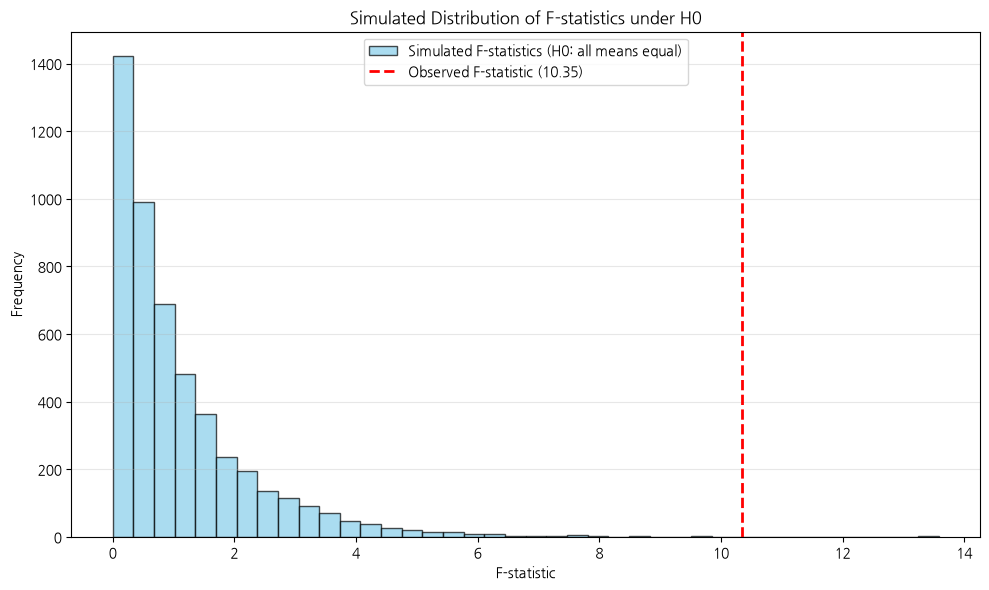

In [34]:
# [문제 5] Q4. 시뮬레이션으로 얻은 F-통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 F-통계량을 세로선으로 함께 표시해 봅시다.

plt.figure(figsize=(10, 6))

plt.hist(simulated_f_stats, bins=40, color='skyblue', edgecolor='black',
          alpha=0.7, label='Simulated F-statistics (H0: all means equal)')

plt.axvline(f_stat, color='red', linestyle='--', linewidth=2,
             label=f'Observed F-statistic ({f_stat:.2f})')

plt.title('Simulated Distribution of F-statistics under H0')
plt.xlabel('F-statistic')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# [문제 5] Q5. 분석 결과를 바탕으로 연구소에 어떤 비료를 추천하시겠습니까?
# 여기에 의견을 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- ANOVA 검정의 p-값을 통해 어떤 결론을 내릴 수 있나요? 이 결과는 "세 비료가 모두 동일한 효과를 가진다"는 뜻인가요, "적어도 하나는 다르다"는 뜻인가요?

- Tukey's HSD 결과표의 `reject` 열에서 `True`로 표시된 조합은 무엇이며, 이는 무엇을 의미하나요?

- `meandiff` 열의 값은 어떤 정보를 주나요? 신뢰구간(`lower`, `upper`)이 0을 포함하는지 여부는 무엇을 뜻할까요?

- 그룹별 표본 크기가 10개로 작다는 점은 이 결론의 신뢰도에 어떤 영향을 줄까요? 어떻게 개선할 수 있을까요?

In [36]:
# [문제 5] 데이터를 어떻게 읽을까요?

# p-값이 0.0005로 유의수준 0.05보다 훨씬 작으므로 귀무가설을 기각합니다. 
# 단, ANOVA가 알려주는 건 정확히 "적어도 하나 이상의 비료는 다른 것들과 평균이 다르다"는 것까지입니다.
# "어느 비료가 다른지"는 ANOVA만으로는 알 수 없고, 그래서 이어지는 Tukey's HSD 사후분석이 필요합니다.

# reject=True는 두 그룹 사이에 통계적으로 유의미한 차이가 있다는 뜻입니다.
# A vs B → True: 유의미하게 다름
# A vs C → False: 유의미한 차이 없음
# B vs C → True: 유의미하게 다름

# meandiff는 두 그룹 평균의 차이입니다.  신뢰구간이 0을 포함하는지가 핵심 판단 기준입니다.
# 0을 포함하지 않으면 "차이가 없다"는 가능성을 배제할 수 있습니다. (유의미한 차이 (reject=True)
# 0을 포함하면 "차이가 없을 수도 있다"가 구간 안에 있습니다. (유의미하지 않음 (reject=False)

# 밭 10개 중 우연히 토양이 좋거나 나쁜 곳이 섞이면 평균이 쉽게 흔들린다면,
# 결과가 "비료 효과"인지 "우연한 밭 차이"인지 확신하기 어렵습니다. 
# 즉 검정력이 부족할 수 있는 위험이 있으며 검정력이 부족하면
# 실제로 차이가 있어도 못 잡아낼 가능성이 있습니다.
# 개선 방법으로는 밭 표본 수를 30~50개로 늘려 반복하거나 
# 토양 비옥도, 일조량 등 밭 간 차이를 통제해 오로지 비료 효과만 볼 수 있도록 합니다.